In [14]:
%pip install uv --quiet
!uv pip install pandas numpy plotly matplotlib
!uv sync

Note: you may need to restart the kernel to use updated packages.


c:\Users\cbutt\OneDrive\Desktop\DataScience\Project\Modern-Store-of-Value\.venv\Scripts\python.exe: No module named pip
Using Python 3.12.3 environment at: c:\Users\cbutt\OneDrive\Desktop\DataScience\Project\Modern-Store-of-Value\.venv
Checked 4 packages in 26ms
Resolved 156 packages in 2ms
Checked 152 packages in 25ms


## Combine csvs

In [15]:
import pandas as pd
import os

BASE_DIR = os.path.abspath("../data")

FILES = {
    "sortino":             os.path.join(BASE_DIR, "sortino_metric.csv"),
    "calmar":              os.path.join(BASE_DIR, "calmar_metrics.csv"),
    "inflation":           os.path.join(BASE_DIR, "inflation_metrics.csv"),
    "market_independence": os.path.join(BASE_DIR, "market_independence_metrics.csv"),
    "crisis":              os.path.join(BASE_DIR, "crisis_metrics.csv"),
}

def load(name: str, path: str) -> pd.DataFrame:
    df = pd.read_csv(path)

    if "Asset_Name" in df.columns:
        df = df.rename(columns={"Asset_Name": "Ticker"})

    rename_map = {
        col: f"{name}__{col}"
        for col in df.columns
        if col != "Ticker"
    }
    return df.rename(columns=rename_map)


dfs = [load(name, path) for name, path in FILES.items()]

merged = dfs[0]
for df in dfs[1:]:
    merged = merged.merge(df, on="Ticker", how="outer")

merged = merged.sort_values("Ticker").reset_index(drop=True)

# ── Consolidate Category columns into one ─────────────────────────────────────
category_cols = [col for col in merged.columns if col.endswith("__Category")]
merged["Category"] = merged[category_cols].bfill(axis=1).iloc[:, 0]
merged = merged.drop(columns=category_cols)

# Move Category to the front, right after Ticker
cols = ["Ticker", "Category"] + [c for c in merged.columns if c not in ("Ticker", "Category")]
merged = merged[cols]

# ── Save ──────────────────────────────────────────────────────────────────────
output_path = os.path.join(BASE_DIR, "merged_metrics.csv")
merged.to_csv(output_path, index=False)

print(f"✅  Merged {len(merged)} tickers × {len(merged.columns)} columns")
print(f"    Saved → {output_path}\n")
print(merged.to_string(max_rows=10))

✅  Merged 23 tickers × 16 columns
    Saved → c:\Users\cbutt\OneDrive\Desktop\DataScience\Project\Modern-Store-of-Value\data\merged_metrics.csv

   Ticker                      Category  sortino__Sortino_Ratio  sortino__Normalized_Sortino_Score_1_10  calmar__Raw_Calmar_Ratio  calmar__Normalized_Calmar_Score_1_10  inflation__Raw_Real_Return_%  inflation__Normalized_Inflation_Score_1_10  market_independence__Raw_Correlation  market_independence__Raw_Beta  market_independence__Correlation_MinMax  market_independence__Beta_MinMax  market_independence__Correlation_Percentile  market_independence__Beta_Percentile  crisis__Raw_Mean_Stress_Score  crisis__Normalized_Crisis_Score_1_10
0    AAPL             Individual Stocks                  1.0685                                    6.73                  0.532745                                  7.55                     72.214169                                        7.95                                0.6545                         1.0348       

## Calculate using Normalized metrics

In [16]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── Load master CSV ───────────────────────────────────────────────────────
BASE_DIR = os.path.abspath("../data")
merged = pd.read_csv(os.path.join(BASE_DIR, "merged_metrics.csv"))

# ── Define the five score columns and their display labels ────────────────
SCORE_COLS = [
    "sortino__Normalized_Sortino_Score_1_10",
    "calmar__Normalized_Calmar_Score_1_10",
    "inflation__Normalized_Inflation_Score_1_10",
    "market_independence__Correlation_Percentile",
    "crisis__Normalized_Crisis_Score_1_10",
]

LABELS = [
    "Sortino\n(Risk-Adj.)",
    "Calmar\n(Drawdown)",
    "Inflation\nAdj. Return",
    "Market\nIndependence",
    "Crisis\nPerformance",
]

# ── Calculate overall score = mean of all five metrics per ticker ─────────
merged["Overall_Score"] = merged[SCORE_COLS].mean(axis=1).round(2)
merged = merged.sort_values("Overall_Score", ascending=False).reset_index(drop=True)
merged["Rank"] = merged.index + 1

print("=== LEADERBOARD ===")
print(merged[["Rank", "Ticker", "Category", "Overall_Score"]].to_string(index=False))

=== LEADERBOARD ===
 Rank Ticker                     Category  Overall_Score
    1    GLD      Commodity ETFs (Metals)           9.02
    2    WMT            Individual Stocks           8.69
    3    DBA Commodity ETFs (Agriculture)           8.36
    4    SLV      Commodity ETFs (Metals)           7.47
    5   NVDA            Individual Stocks           7.06
    6    XLU                  Sector ETFs           6.97
    7   IBIT                  Crypto ETFs           6.81
    8   PPLT      Commodity ETFs (Metals)           6.64
    9   AAPL            Individual Stocks           6.15
   10    JNJ            Individual Stocks           5.99
   11    AMD            Individual Stocks           5.83
   12    VTI            Broad Market ETFs           5.81
   13    SPY            Broad Market ETFs           5.75
   14   SOYB Commodity ETFs (Agriculture)           5.26
   15   MSFT            Individual Stocks           4.76
   16   WEAT Commodity ETFs (Agriculture)           3.95
   17    LO

## Calculate using raw metric values (Normalized 1-10)

In [17]:
# # ── Define direction of each metric ───────────────────────────────────────
# # True = Higher is better (e.g., Returns)
# # False = Lower is better (e.g., Stress/Correlation)
# METRIC_DIRECTIONS = {
#     "sortino__Sortino_Ratio": True,
#     "calmar__Raw_Calmar_Ratio": True,
#     "inflation__Raw_Real_Return_%": True,
#     "market_independence__Raw_Correlation": False,
#     "crisis__Raw_Mean_Stress_Score": False
# }

# SCORE_COLS = list(METRIC_DIRECTIONS.keys())
# normalized_col_names = []

# # ── Perform Min-Max Normalization (1-10 Scale) ───────────────────────────
# for col, higher_is_better in METRIC_DIRECTIONS.items():
#     norm_name = f"norm_{col}"
#     normalized_col_names.append(norm_name)
    
#     col_min = merged[col].min()
#     col_max = merged[col].max()
    
#     if higher_is_better:
#         # Standard: 10 is the Max, 1 is the Min
#         merged[norm_name] = 1 + 9 * (merged[col] - col_min) / (col_max - col_min)
#     else:
#         # Inverted: 10 is the Min (best), 1 is the Max (worst)
#         merged[norm_name] = 1 + 9 * (col_max - merged[col]) / (col_max - col_min)

# # ── Calculate overall score = mean of normalized metrics ─────────────────
# merged["Overall_Score"] = merged[normalized_col_names].mean(axis=1).round(2)
# merged = merged.sort_values("Overall_Score", ascending=False).reset_index(drop=True)
# merged["Rank"] = merged.index + 1

# print("=== LINEAR LEADERBOARD (Normalized 1-10) ===")
# print(merged[["Rank", "Ticker", "Category", "Overall_Score"]].to_string(index=False))

In [18]:
# ── Success Metric Rankings: Top 3 Analysis ───────────────────────────────────

# Define the columns we want to rank (from radar_chart.ipynb)
metrics_to_rank = {
    "Downside Efficiency (Sortino)": "sortino__Normalized_Sortino_Score_1_10",
    "Drawdown Resilience (Calmar)": "calmar__Normalized_Calmar_Score_1_10",
    "Inflation Protection (Real Return)": "inflation__Normalized_Inflation_Score_1_10",
    "Market Independence (Correlation)": "market_independence__Correlation_Percentile",
    "Crisis Performance (Stress Test)": "crisis__Normalized_Crisis_Score_1_10"
}

print("=== INDIVIDUAL METRIC TOP 3 RANKINGS ===\n")

for label, col in metrics_to_rank.items():
    # Sort by the specific metric and take the top 3
    top_3 = merged.sort_values(col, ascending=False).head(3)
    
    print(f"--- {label} ---")
    print(top_3[["Ticker", "Category", col]].to_string(index=False))
    print("\n" + "="*40 + "\n")


=== INDIVIDUAL METRIC TOP 3 RANKINGS ===

--- Downside Efficiency (Sortino) ---
Ticker                Category  sortino__Normalized_Sortino_Score_1_10
  NVDA       Individual Stocks                                   10.00
   WMT       Individual Stocks                                    9.59
   GLD Commodity ETFs (Metals)                                    9.18


--- Drawdown Resilience (Calmar) ---
Ticker                Category  calmar__Normalized_Calmar_Score_1_10
   WMT       Individual Stocks                                 10.00
  NVDA       Individual Stocks                                  9.59
   GLD Commodity ETFs (Metals)                                  9.18


--- Inflation Protection (Real Return) ---
Ticker                Category  inflation__Normalized_Inflation_Score_1_10
  NVDA       Individual Stocks                                       10.00
   WMT       Individual Stocks                                        9.59
   SLV Commodity ETFs (Metals)                     

In [19]:
def create_individual_radar(ticker_name, dataframe, save_output=False):
    """
    Creates and displays a radar chart for a specific ticker using 
    the team's standardized 1-10 normalized scores.
    """
    # 1. Configuration (Matching radar_chart.ipynb schema)
    categories = [
        "Risk-Adjusted<br>Returns",  # Top of radar plot, rotating clockwise
        "Real<br>Returns", 
        "Crisis<br>Performance", 
        "Market<br>Independence", 
        "Drawdown<br>Protection"
    ]
    
    metric_cols = [
        "sortino__Normalized_Sortino_Score_1_10",
        "inflation__Normalized_Inflation_Score_1_10",
        "calmar__Normalized_Calmar_Score_1_10",
        "market_independence__Correlation_Percentile",
        "crisis__Normalized_Crisis_Score_1_10"
    ]

    # 2. Extract Data
    ticker_data = dataframe[dataframe['Ticker'] == ticker_name]
    
    if ticker_data.empty:
        print(f"Error: Ticker '{ticker_name}' not found in the dataset.")
        return

    # Extract values and close the radar loop
    values = ticker_data[metric_cols].values.flatten().tolist()
    values_closed = values + [values[0]]
    categories_closed = categories + [categories[0]]

    # 3. Create Figure
    fig = go.Figure()
    fig.add_trace(go.Scatterpolar(
        r=values_closed,
        theta=categories_closed,
        fill='toself',
        name=ticker_name,
        line=dict(color='#636EFA', width=3),
        fillcolor='rgba(99, 110, 250, 0.3)'
    ))

    fig.update_layout(
        polar=dict(
            radialaxis=dict(visible=True, range=[0, 10], gridcolor="lightgrey"),
            angularaxis=dict(rotation=90, direction="clockwise")
        ),
        
        # title=dict(
        #     text=f"<b>Performance Fingerprint: {ticker_name}</b>",
        #     x=0.5,
        #     font=dict(size=18)
        # ),
        
        template="plotly_white",
        width=500,
        height=500
    )

    # 4. Save Logic
    # if save_output:
    #     output_dir = "../plots/individual_radars"
    #     os.makedirs(output_dir, exist_ok=True)
    #     fig.write_image(os.path.join(output_dir, f"radar_{ticker_name}.png") )
    #     print(f"✅ Saved radar_{ticker_name}.png to {output_dir}")

    fig.show()

In [20]:
target_tickers = [
    "GLD", 
    "WMT", 
    "DBA", 
    "NVDA", 
    "WEAT"
]

for i in target_tickers:
    create_individual_radar(i, merged)

In [21]:
import plotly.express as px

# 1. Prepare the data (Ensure it is sorted by score)
leaderboard_df = merged.sort_values("Overall_Score", ascending=True)

# 2. Create the Horizontal Lollipop Chart
fig = px.scatter(
    leaderboard_df, 
    x="Overall_Score", 
    y="Ticker", 
    color="Overall_Score",
    color_continuous_scale="RdYlGn",  # Red-Yellow-Green gradient
    title="<b>Modern Store of Value: Overall Success Leaderboard</b>",
    labels={"Overall_Score": "Overall Success Score (1-10)"},
    height=800,
    text="Overall_Score"  # Add score labels on the dots
)

# 3. Add the 'Lollipop' sticks to give it that geometric look
for i, row in leaderboard_df.iterrows():
    fig.add_shape(
        type='line',
        x0=0, y0=row['Ticker'],
        x1=row['Overall_Score'], y1=row['Ticker'],
        line=dict(color='rgba(200, 200, 200, 0.5)', width=2),
        layer='below'
    )

# 4. Stylize the markers and layout
fig.update_traces(
    marker=dict(size=14, opacity=1, line=dict(width=1, color='DarkSlateGrey')),
    textposition='middle right',
    textfont=dict(color='black', size=10)
)

fig.update_layout(
    xaxis=dict(range=[0, 11], dtick=1, gridcolor="#f0f0f0"),
    yaxis=dict(title="Asset Ticker"),
    template="plotly_white",
    coloraxis_showscale=False,  # Hide the color bar for a cleaner look
    margin=dict(l=100, r=50, t=80, b=50)
)

fig.show()

In [ ]:
# ── Create the Success Leaderboard Table with Inline Bars ───────────────────

# 1. Prepare the DataFrame subset and sort by Score
table_df = merged[["Ticker", "Category", "Overall_Score"]].copy()
table_df = table_df.sort_values("Overall_Score", ascending=False)

# 2. Define the Styling Function
styled_table = table_df.style.bar(
    subset=['Overall_Score'], 
    color='#636EFA',  # Professional blue matching your radar charts
    vmin=0, vmax=10, 
    width=40          # Adjust width of the bar within the cell
).format({
    "Overall_Score": "{:.2f}"
}).set_properties(**{
    'text-align': 'left',
    'font-family': 'Arial',
    'border-color': 'lightgrey'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#f2f2f2'), ('color', 'black'), ('font-weight', 'bold')]}
])

# 3. Display the Table
styled_table

,Ticker,Category,Overall_Score
0,GLD,Commodity ETFs (Metals),9.02
1,WMT,Individual Stocks,8.69
2,DBA,Commodity ETFs (Agriculture),8.36
3,SLV,Commodity ETFs (Metals),7.47
4,NVDA,Individual Stocks,7.06
5,XLU,Sector ETFs,6.97
6,IBIT,Crypto ETFs,6.81
7,PPLT,Commodity ETFs (Metals),6.64
8,AAPL,Individual Stocks,6.15
9,JNJ,Individual Stocks,5.99


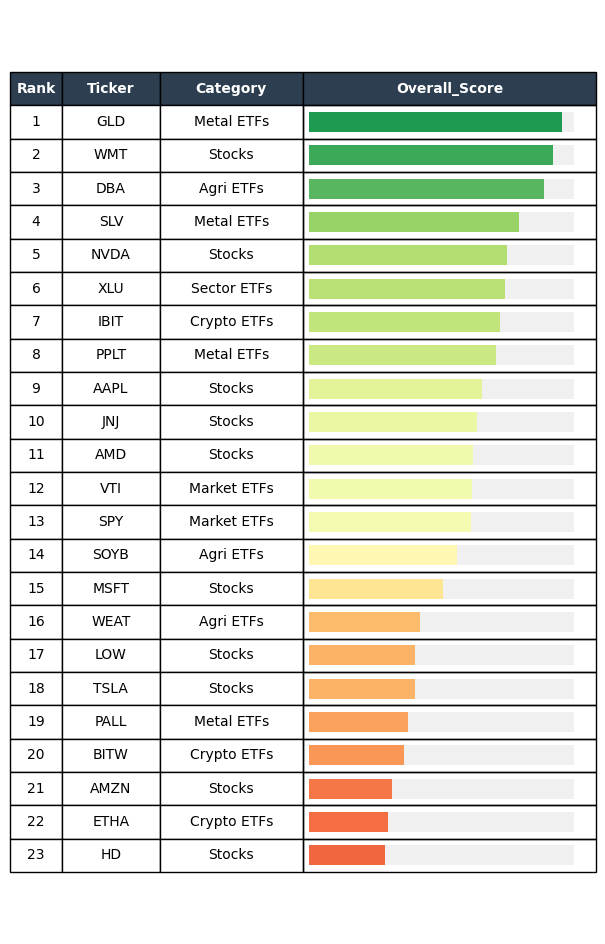

In [33]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import numpy as np

# 1. Prepare Data and Shorten Category Names
# We use the mapping from our previous successful iterations
cat_map = {
    "Commodity ETFs (Metals)": "Metal ETFs",
    "Individual Stocks": "Stocks",
    "Commodity ETFs (Agriculture)": "Agri ETFs",
    "Sector ETFs": "Sector ETFs",
    "Broad Market ETFs": "Market ETFs",
    "Crypto ETFs": "Crypto ETFs"
}

# Create the display dataframe
df_display = merged.copy()
df_display["Category"] = df_display["Category"].map(cat_map).fillna(df_display["Category"])
df_display = df_display.sort_values("Overall_Score", ascending=False).reset_index(drop=True)
df_display["Rank"] = df_display.index + 1

# Reorder Columns: Rank -> Ticker -> Category -> Overall_Score
df_final = df_display[["Rank", "Ticker", "Category", "Overall_Score"]]

# 2. Setup the Plot
fig, ax = plt.subplots(figsize=(7, 12)) 
ax.axis('off')

# Define Color Gradient (Red -> Yellow -> Green)
cmap = plt.cm.RdYlGn
norm = plt.Normalize(vmin=1, vmax=10)

# 3. Create the Table
table = ax.table(
    cellText=df_final.values,
    colLabels=df_final.columns,
    loc='center',
    cellLoc='center',
    colWidths=[0.08, 0.15, 0.22, 0.45]
)

# 4. Custom Styling
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 2.0) # Adjust row height and column width

fig.canvas.draw()

for i in range(len(df_final)):
    # Get the Score Cell (Row i+1, Col 3)
    cell = table[(i+1, 3)]
    score = df_final.iloc[i]["Overall_Score"]
    
    # Get cell geometry
    bbox = cell.get_window_extent(fig.canvas.get_renderer())
    bbox_ax = bbox.transformed(ax.transData.inverted())
    
    # Calculate bar width proportional to score (score/10)
    # We leave a small margin (5%) so the bar doesn't touch the borders
    padding = 0.02
    bar_max_width = bbox_ax.width * (1 - 2*padding)
    bar_width = bar_max_width * (score / 10.0)
    bar_height = bbox_ax.height * 0.6
    
    # Determine Color from Gradient
    bar_color = cmap(norm(score))
    
    # Draw Background "Track" (Light Gray)
    rect_bg = patches.Rectangle(
        (bbox_ax.x0 + bbox_ax.width*padding, bbox_ax.y0 + bbox_ax.height*0.2),
        bar_max_width, bar_height,
        facecolor='#f0f0f0', edgecolor='none', zorder=1
    )
    ax.add_patch(rect_bg)
    
    # Draw Success Bar (Proportional Width)
    rect_bar = patches.Rectangle(
        (bbox_ax.x0 + bbox_ax.width*padding, bbox_ax.y0 + bbox_ax.height*0.2),
        bar_width, bar_height,
        facecolor=bar_color, edgecolor='none', zorder=2
    )
    ax.add_patch(rect_bar)
    
    # Re-style the text to be bold and on top of the bar
    cell.get_text().set_weight('bold')
    cell.get_text().set_zorder(3)
    # Clear the cell facecolor to show the patches underneath
    cell.set_facecolor('none')

# 6. Style the Header Row
for j in range(len(df_final.columns)):
    header_cell = table[(0, j)]
    header_cell.set_facecolor('#2c3e50')
    header_cell.get_text().set_color('white')
    header_cell.get_text().set_weight('bold')
    table[(0, j)].get_text().set_weight('bold')

# plt.title("Consolidated Success Metrics: Final Ranking", fontsize=16, fontweight='bold', pad=30)

# 5. Save as High-Res for the Poster
# plt.savefig("Poster_Table_Leaderboard.png", dpi=300, bbox_inches='tight')
# plt.show()

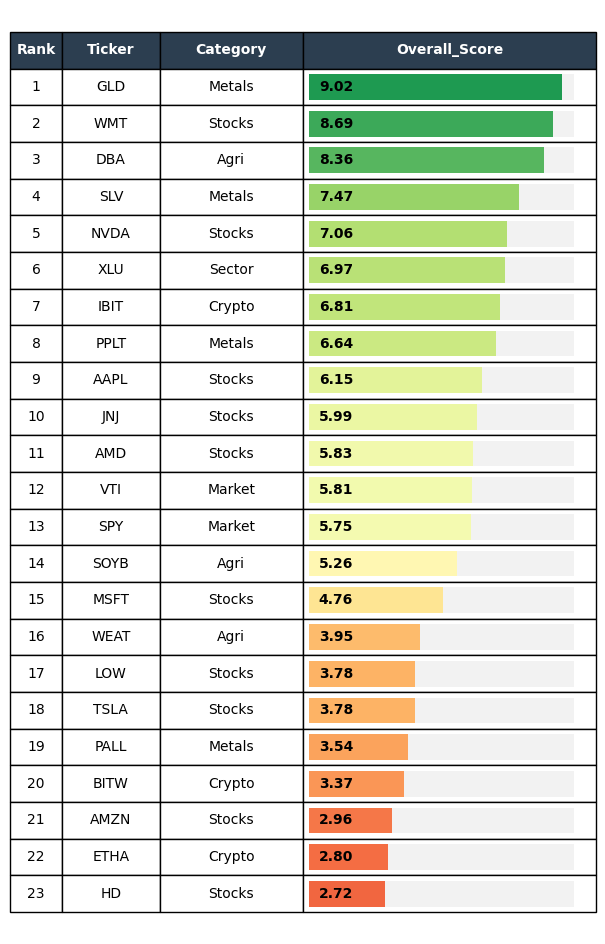

In [45]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import numpy as np

# 1. Prepare Data
cat_map = {
    "Commodity ETFs (Metals)": "Metals",
    "Individual Stocks": "Stocks",
    "Commodity ETFs (Agriculture)": "Agri",
    "Sector ETFs": "Sector",
    "Broad Market ETFs": "Market",
    "Crypto ETFs": "Crypto"
}

df_display = merged.copy()
df_display["Category"] = df_display["Category"].map(cat_map).fillna(df_display["Category"])
df_display = df_display.sort_values("Overall_Score", ascending=False).reset_index(drop=True)
df_display["Rank"] = df_display.index + 1

df_final = df_display[["Rank", "Ticker", "Category", "Overall_Score"]]

# 2. Setup Plot
fig, ax = plt.subplots(figsize=(7, 12)) 
ax.axis('off')

cmap = plt.cm.RdYlGn
norm = plt.Normalize(vmin=1, vmax=10)

# 3. Create Table
# Note: We leave Overall_Score as empty strings in the cell text so we can manually overlay
table_data = df_final.copy()
table_data["Overall_Score"] = "" # Clear text from the data to avoid double-text

table = ax.table(
    cellText=table_data.values,
    colLabels=df_final.columns,
    loc='center',
    cellLoc='center',
    colWidths=[0.08, 0.15, 0.22, 0.45] 
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 2.2) 

# 4. Manual Overlay Logic (Bars + Text Labels)
fig.canvas.draw()
renderer = fig.canvas.get_renderer()

for i in range(len(df_final)):
    score = df_final.iloc[i]["Overall_Score"]
    cell = table[(i+1, 3)]
    
    # Get precise cell coordinates
    bbox = cell.get_window_extent(renderer)
    bbox_ax = bbox.transformed(ax.transData.inverted())
    
    # Bar proportions
    padding_x = 0.02
    padding_y = 0.15
    bar_max_width = bbox_ax.width * (1 - 2*padding_x)
    bar_width = bar_max_width * (score / 10.0)
    bar_height = bbox_ax.height * 0.7
    
    # Draw Background
    ax.add_patch(patches.Rectangle(
        (bbox_ax.x0 + bbox_ax.width*padding_x, bbox_ax.y0 + bbox_ax.height*padding_y),
        bar_max_width, bar_height, facecolor='#f2f2f2', zorder=1
    ))
    
    # Draw Success Bar
    color = cmap(norm(score))
    ax.add_patch(patches.Rectangle(
        (bbox_ax.x0 + bbox_ax.width*padding_x, bbox_ax.y0 + bbox_ax.height*padding_y),
        bar_width, bar_height, facecolor=color, zorder=2
    ))
    
    # 5. LEFT-ALIGNED TEXT OVERLAY
    # We place the text at the start of the bar + a tiny offset (0.015) for breathing room
    text_x = bbox_ax.x0 + (bbox_ax.width * padding_x) + 0.05
    text_y = bbox_ax.y0 + (bbox_ax.height / 2)
    text_color = "black"
    

    
    
    ax.text(
        text_x, text_y, f"{score:.2f}",
        ha='center', va='center', weight='bold', 
        color=text_color, fontsize=10, zorder=5
    )

# 6. Style Headers
for j in range(len(df_final.columns)):
    header = table[(0, j)]
    header.set_facecolor('#2c3e50')
    header.get_text().set_color('white')
    header.get_text().set_weight('bold')

# plt.title("Modern Store of Value: Final Success Leaderboard", fontsize=16, fontweight='bold', pad=30)
# plt.savefig("Final_Poster_Leaderboard_Fixed.png", dpi=300, bbox_inches='tight')
# plt.show()